# 05. Baseline Model - Decision Tree
**Project:** Automobile Loan Default Prediction  
**Goal:** Train and test a simple Decision Tree baseline model.

### 1. Load Libraries

In [1]:
import sys
import joblib
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, precision_recall_curve

# Import our helper functions from src
sys.path.append("..")
from src.models.decision_tree import train_decision_tree, evaluate_decision_tree, save_decision_tree_model

### 2. Load Train and Test Data

In [2]:
X_train = joblib.load("../data/processed/X_train.joblib")
y_train = joblib.load("../data/processed/y_train.joblib")
X_test = joblib.load("../data/processed/X_test.joblib")
y_test = joblib.load("../data/processed/y_test.joblib")

print("Training samples:", X_train.shape[0])
print("Testing samples: ", X_test.shape[0])

Training samples: 97484
Testing samples:  24372


### 3. Train Decision Tree
We set `max_depth=6` and `class_weight='balanced'`.

In [3]:
model, train_time = train_decision_tree(X_train, y_train, max_depth=6, min_samples_leaf=20)
print(f"Trained in {train_time:.2f} seconds.")

Trained in 1.50 seconds.


### 4. Model Evaluation

In [4]:
metrics, cm = evaluate_decision_tree(model, X_test, y_test)

# Show simple metrics table
results = pd.DataFrame([
    {"Metric": "Accuracy", "Score": metrics["accuracy"]},
    {"Metric": "Precision (Default)", "Score": metrics["precision"]},
    {"Metric": "Recall (Default)", "Score": metrics["recall"]},
    {"Metric": "F1-Score", "Score": metrics["f1_score"]},
    {"Metric": "ROC-AUC", "Score": metrics["roc_auc"]},
    {"Metric": "PR-AUC", "Score": metrics["pr_auc"]},
])
results

,Metric,Score
0,Accuracy,0.6837
1,Precision (Default),0.1466
2,Recall (Default),0.6049
3,F1-Score,0.2360
4,ROC-AUC,0.7058
5,PR-AUC,0.1727


### 5. Confusion Matrix

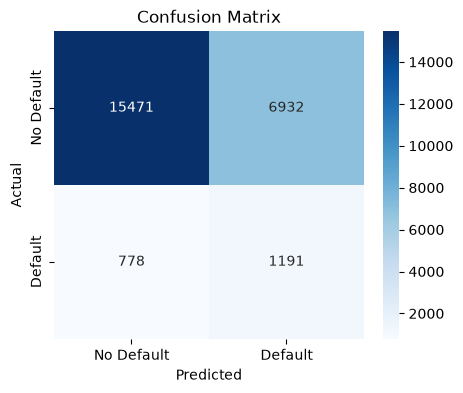

Correct Non-Defaults (TN): 15471 | Wrong Alarms (FP): 6932
Missed Defaults (FN):      778  | Caught Defaults (TP): 1191


In [5]:
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", 
            xticklabels=["No Default", "Default"],
            yticklabels=["No Default", "Default"])
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

print(f"Correct Non-Defaults (TN): {metrics['tn']} | Wrong Alarms (FP): {metrics['fp']}")
print(f"Missed Defaults (FN):      {metrics['fn']}  | Caught Defaults (TP): {metrics['tp']}")

### 6. ROC and Precision-Recall Curves

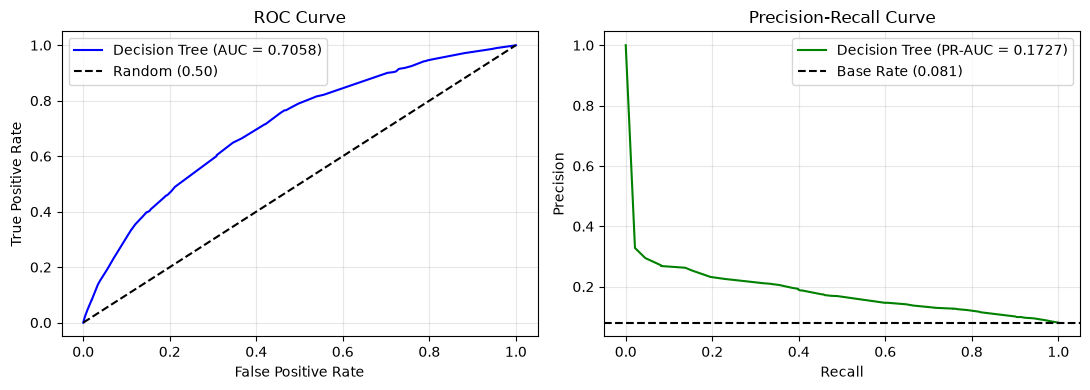

In [6]:
y_proba = model.predict_proba(X_test)[:, 1]

fpr, tpr, _ = roc_curve(y_test, y_proba)
precision_vals, recall_vals, _ = precision_recall_curve(y_test, y_proba)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# ROC Curve
axes[0].plot(fpr, tpr, label=f"Decision Tree (AUC = {metrics['roc_auc']})", color="blue")
axes[0].plot([0, 1], [0, 1], "k--", label="Random (0.50)")
axes[0].set_title("ROC Curve")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Precision-Recall Curve
axes[1].plot(recall_vals, precision_vals, label=f"Decision Tree (PR-AUC = {metrics['pr_auc']})", color="green")
axes[1].axhline(y=y_test.mean(), color="k", linestyle="--", label=f"Base Rate ({y_test.mean():.3f})")
axes[1].set_title("Precision-Recall Curve")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 7. Save Model

In [7]:
save_decision_tree_model(model, "../models/baseline/decision_tree.pkl")

Model saved to ../models/baseline/decision_tree.pkl


'../models/baseline/decision_tree.pkl'

### 8. Why These Settings Were Used

#### 1. Why `class_weight='balanced'`?
* In this dataset, **92%** of people pay their loan on time, and only **8%** default.
* If we do not use `balanced`, the tree will simply predict "No Default" for everyone. That gives a fake high accuracy of 92%, but catches **0 defaulters**.
* Setting `class_weight='balanced'` forces the tree to pay attention to defaulters, allowing it to catch **~60% of real defaulters**.

#### 2. Why `max_depth=6`?
* If a decision tree is allowed to grow with no limit, it grows 20+ levels deep and memorizes noise in the training data (overfitting).
* Capping the depth at **6** keeps the rules simple and prevents overfitting, so the model works well on new test data.